# ロジスティック回帰による異常検知の実装

ここでは2章で作成したサンプルデータを使用して、ロジスティック回帰による異常検知をPythonで実装します。

Pythonでロジスティック回帰による分類を行うには、scikit-learnの[`sklearn.linear_model.
LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)クラスを使用すると便利です。具体的な実装を学習と推論に分けて解説します。

## 学習

次のコードでは、正常と異常のラベルを目的変数としてロジスティック回帰で学習を行い、決定境界を描画しています（説明変数は5変数のうち`temp1`と`temp2`の2変数を使用）。

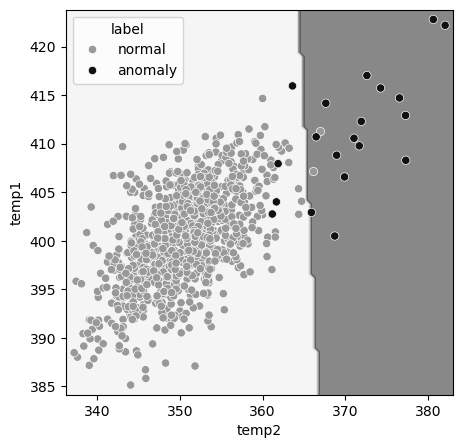

In [1]:
# コード3.5 異常と正常を判別するロジスティック回帰モデルの学習
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.cm as cm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSVからPandas DataFrameにデータ読込
df = pd.read_csv("./datasets/ch2_dataset_train.csv")

# "temp2","temp1"変数に欠測があるデータを削除
df_dropna = df.dropna(subset=["temp2", "temp1"])
# データをnumpy.ndarrayに変換
X = df_dropna[["temp2","temp1"]].to_numpy() # 説明変数（2変数のみ使用）
y = df_dropna["label"].to_numpy() # ラベルデータ（目的変数）
# ロジスティック回帰モデルを学習
clf = LogisticRegression(penalty=None)
clf.fit(X, y)
# 決定境界をプロット
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
disp = DecisionBoundaryDisplay.from_estimator(
    clf, X, response_method="predict",
    xlabel="temp2", ylabel="temp1",
    cmap=cm.gray, alpha=0.5, ax=ax
)
# 散布図を重ねてプロット
sns.scatterplot(data=df_dropna, x="temp2", y="temp1",
    hue="label", palette=["#999999", "#111111"],
    ax=ax
)
plt.show()

SVMと同様、ロジスティック回帰も欠測値があるデータには適用できないため、事前に9章で紹介する方法で欠測データを除去または補完する必要があります。
またscikit-learnの`sklearn.linear_model.LogisticRegression`クラスは、単純な最尤推定による学習に加え、SVMのソフトマージンと同様の役割を果たす正則化項を最⼤化関数に加えることができます。正則化の種類は`penalty`引数で指定でき、デフォルトでは`"l2"`（L2 正則化）が適用されていますが、今回は正則化を適用しないため、`penalty=None`を指定しています。

図を見ると、ガウスカーネルを用いたSVMと異なり、決定境界が直線であることがわかります。

## 推論

推論は、上記で学習したモデル（clf）の`predict`メソッドを用いることで実行できます。

In [2]:
# コード3.6 ロジスティック回帰モデルの推論
# 推論データを読み込み
df_inference = pd.read_csv("./datasets/ch2_dataset_inference.csv")
# "temp2","temp1"変数に欠測があるデータを削除
df_inference_dropna = df_inference.dropna(subset=["temp2", "temp1"])
# データから2変数のみ取り出してnumpy.ndarrayに変換
X_inference = df_inference_dropna[["temp2","temp1"]].to_numpy()
# 学習済みのロジスティック回帰モデルで推論
y_pred = clf.predict(X_inference)
# 推論結果を表示
print(y_pred)

['normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal' 'normal' 'normal' 'norm

### クラス確率のプロット

ロジスティック回帰はその計算過程で各クラス（ラベル）に属する確率$p(y = c_k \mid \boldsymbol{x})$を求めていますが、scikit-learnではこの確率を`predict_proba`メソッドで取得できます。以下に示す実装例では、先ほどの実装例の学習済みモデルから取得したクラス確率をプロットしています。

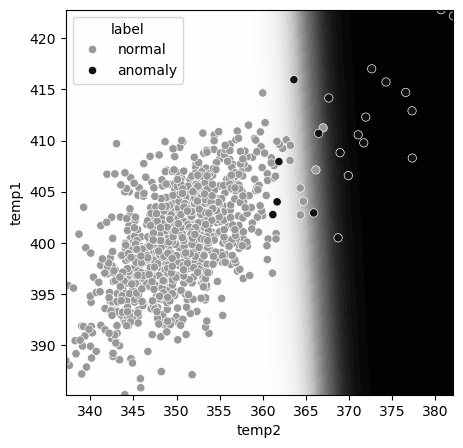

In [3]:
# コード3.7 ロジスティック回帰により求めたクラス確率の描画
import numpy as np

# クラス確率描画用のメッシュデータを作成
temp2_min, temp2_max = np.min(X[:, 0]), np.max(X[:, 0])
temp1_min, temp1_max = np.min(X[:, 1]), np.max(X[:, 1])
temp2_axis = np.linspace(temp2_min, temp2_max, num=100)
temp1_axis = np.linspace(temp1_min, temp1_max, num=100)
X_temp2, X_temp1= np.meshgrid(temp2_axis, temp1_axis)
X_grid = np.c_[X_temp2.ravel(), X_temp1.ravel()]
# 学習済みモデルからクラス確率を取得
y_proba_grid = clf.predict_proba(X_grid)
# 異常確率を抽出してピボット化
anomaly_proba_pivot = y_proba_grid[:, 0].reshape(X_temp2.shape)
# クラス確率をプロット
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
ax.contourf(X_temp2, X_temp1, anomaly_proba_pivot, levels=50, cmap="Greys")
# 散布図を重ねてプロット
sns.scatterplot(data=df_dropna, x="temp2", y="temp1",
                hue="label", palette=["#999999", "#111111"],
                ax=ax)
plt.show()

図を見ると、決定境界付近でクラス確率が急激に変化していることが分かります。

### ロジスティック回帰以外の手法でのクラス確率の予測

scikit-learnでは、ロジスティック回帰以外の多くの分類アルゴリズムにおいても、各クラスに属する確率、すなわちクラス確率を`predict_proba`メソッドで求めることができます。SVMにおいては[Platt Scaling](https://scikit-learn.org/0.18/modules/svm.html#scores-and-probabilities)と呼ばれる方法で、SVMの学習済みモデルに後付けでロジスティック関数をフィッティングすることで、クラス確率を求められます。

以下の実装例では、SVMのクラス確率を求めて推論データと一緒にプロットしています。クラス確率を求めるためには、`SVC`クラスのコンストラクタに`probability=True`を渡す必要があることにご注意ください。

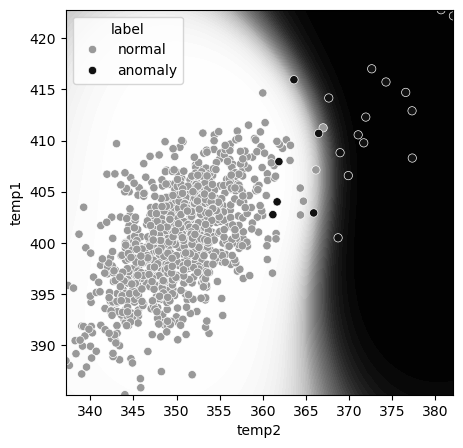

In [4]:
# SVMでのクラス確率の予測
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# SVMモデルを学習（probability=Trueを指定する必要がある）
svm = SVC(C=10, gamma=0.1, probability=True)
clf = Pipeline([("scaler", StandardScaler()), ("svm", svm)])
clf.fit(X, y)

# 学習済みモデルからクラス確率を取得
y_proba_grid = clf.predict_proba(X_grid)
# 異常確率を抽出してピボット化
anomaly_proba_pivot = y_proba_grid[:, 0].reshape(X_temp2.shape)
# クラス確率をプロット
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
ax.contourf(X_temp2, X_temp1, anomaly_proba_pivot, levels=50, cmap="Greys")
# 散布図を重ねてプロット
sns.scatterplot(data=df_dropna, x="temp2", y="temp1",
                hue="label", palette=["#999999", "#111111"],
                ax=ax)
plt.show()

ロジスティック回帰と比べ、SVMはより曲線的なクラス確率の分布を持ちます。これはカーネルトリックにより曲線的な決定境界が引かれていることに由来します。